<a href="https://colab.research.google.com/github/Gautam2-468/Breast-cancer-prediction/blob/main/knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Prediction using K-Nearest Neighbors (KNN)

## Project Introduction

This project aims to classify breast cancer as Malignant (M) or Benign (B) using the K-Nearest Neighbors (KNN) algorithm. The dataset utilized for this classification task is the Breast Cancer Wisconsin (Diagnostic) Dataset.

The process involves several key steps:
1.  **Data Loading and Initial Inspection**: Loading the dataset and performing an initial check on its structure and missing values.
2.  **Data Preprocessing**: Cleaning the data by dropping irrelevant columns and encoding categorical target variables.
3.  **Exploratory Data Analysis (EDA)**: Visualizing data distributions and correlations to understand the relationships between features and the target variable.
4.  **Data Splitting**: Dividing the dataset into training and testing sets.
5.  **Feature Scaling**: Applying standardization to features, which is crucial for distance-based algorithms like KNN.
6.  **Model Training**: Implementing and training the KNN classifier.
7.  **Model Evaluation**: Assessing the model's performance using metrics such as accuracy, confusion matrix, and classification report.
8.  **Hyperparameter Tuning**: Experimenting with different values of 'k' to find the optimal number of neighbors that yields the best performance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/data.csv")
df.head(11)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750,NaN


In [ ]:
df.shape


(569, 33)

In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
df.drop(["id", "Unnamed: 32"], axis=1, inplace=True)

In [ ]:

df["diagnosis"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

In [ ]:
df.corr(numeric_only=True)["diagnosis"].sort_values(ascending=False)

,diagnosis
diagnosis,1.000000
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360


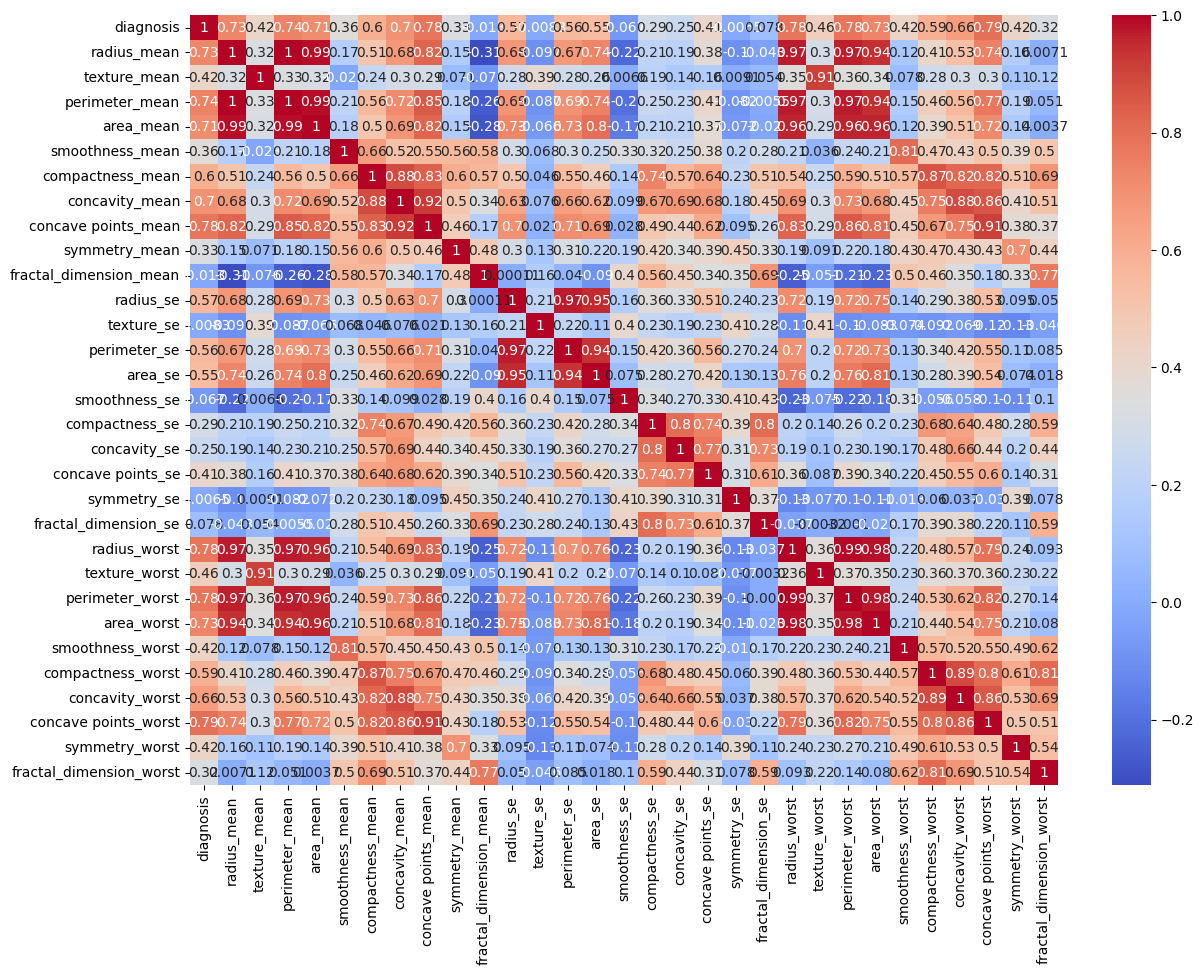

In [ ]:
plt.figure(figsize=(14,10 ))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

<Axes: xlabel='diagnosis', ylabel='count'>

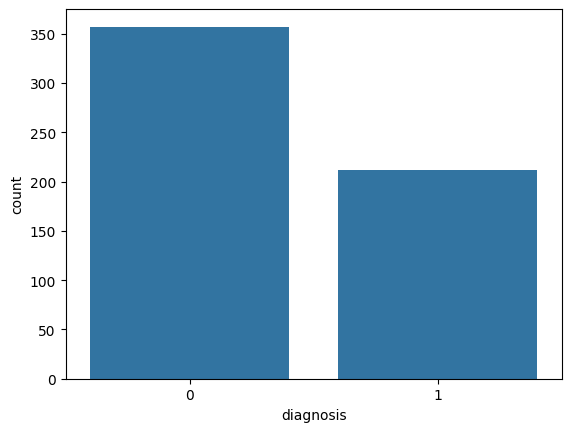

In [ ]:
sns.countplot(x="diagnosis", data=df)

<Axes: xlabel='diagnosis', ylabel='radius_worst'>

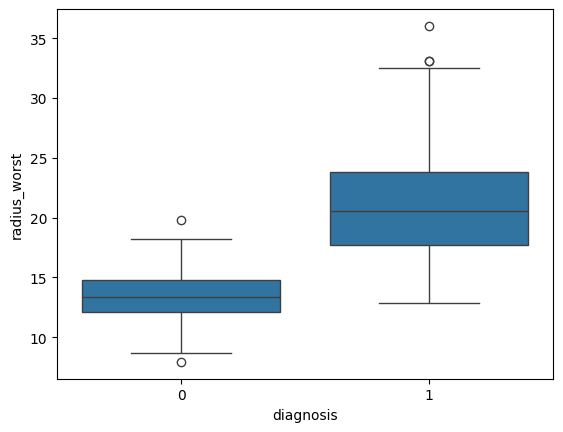

In [ ]:
sns.boxplot(
    x="diagnosis",
    y="radius_worst",
    data=df
)

<Axes: xlabel='diagnosis', ylabel='perimeter_worst'>

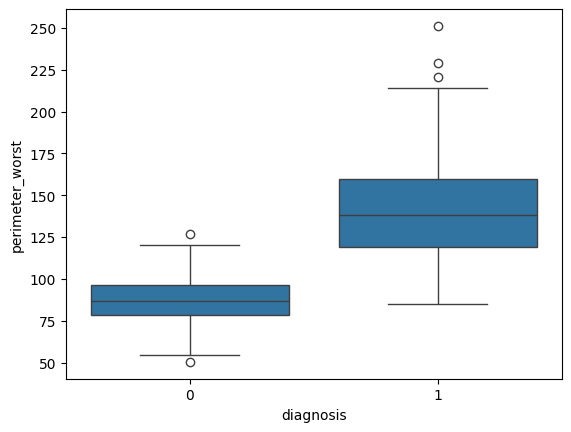

In [ ]:
sns.boxplot(
    x="diagnosis",
    y="perimeter_worst",
    data=df
)

In [ ]:
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(
    n_neighbors=5
)

model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
train_acc = model.score(X_train, y_train)

test_acc = model.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.9582417582417583
0.9473684210526315


<Axes: >

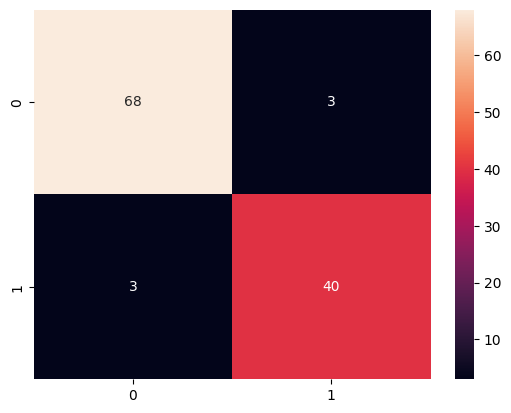

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
train_acc = []
test_acc = []

for k in range(1,21):

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(X_train,y_train)

    train_acc.append(
        model.score(X_train,y_train)
    )

    test_acc.append(
        model.score(X_test,y_test)
    )
best_k = test_acc.index(max(test_acc)) + 1

print("Best K =", best_k)

print("Best Accuracy =", max(test_acc))

Best K = 9
Best Accuracy = 0.9649122807017544


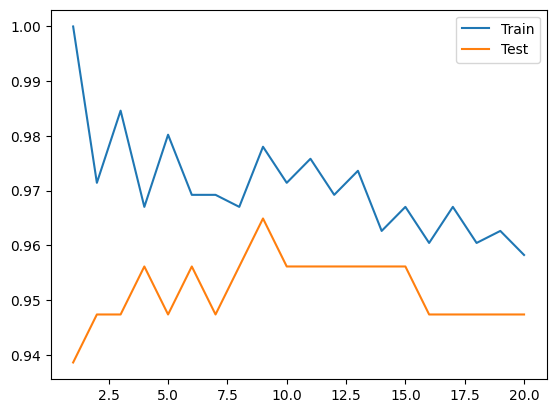

In [ ]:
plt.plot(range(1,21),train_acc,label="Train")

plt.plot(range(1,21),test_acc,label="Test")

plt.legend()

plt.show()

## Conclusion

In this project, the K-Nearest Neighbors (KNN) algorithm was implemented on the Breast Cancer dataset to classify tumors as Malignant (M) or Benign (B).

The dataset was first cleaned by removing unnecessary columns and encoding categorical values. Since KNN is a distance-based algorithm, feature scaling was applied using StandardScaler to ensure that all features contributed equally to the distance calculations.

Different values of K were tested to identify the optimal number of neighbors. The model was evaluated using Accuracy Score, Confusion Matrix, and Classification Report.

The results showed that KNN performed well on the dataset and achieved high classification accuracy. The project also demonstrated the importance of feature scaling and hyperparameter tuning in improving model performance.

Overall, KNN proved to be an effective algorithm for breast cancer classification and provided a strong understanding of distance-based machine learning techniques.
